# 🌡️ Urban Heat Island Planner: Reinforcement Learning Training

Welcome to the **Urban Heat Island Planner** training notebook! This notebook demonstrates how we train an intelligent city planner agent using Reinforcement Learning (specifically, Hugging Face's TRL framework) to mitigate extreme urban heat.

### 🌟 The Hackathon Challenge
Our environment tests the agent on three core themes:
1. **Long-Horizon Planning:** The agent must plant trees early (they take 1 year to grow) to survive the Summer Heatwaves.
2. **World Modeling:** The agent cannot just place interventions magically. It must navigate enterprise-like APIs (`query_zoning`, `propose_budget`, `deploy_intervention`).
3. **Multi-Agent Interactions:** The agent's budget proposals are evaluated by a simulated "Mayor" who has hidden biases (e.g., rejecting projects in low-density zones).

### 🛠️ Notebook Architecture
Because our environment is designed as a robust `FastAPI` server, this notebook will:
1. Clone our environment code from GitHub.
2. Start the FastAPI server silently in the background.
3. Execute our PPO training loop (`train_trl.py`) against the running server.

---
## Step 1: Environment Setup
First, we clone the official repository and install the required dependencies to run both the FastAPI server and the Hugging Face TRL training loop.

In [2]:
!git clone https://github.com/Shoaibahmed-2005/Urban-Heat-Round-2.git urban_heat_env
%cd urban_heat_env

# Install core environment requirements and TRL libraries
!pip install -r requirements.txt
!pip install trl==0.8.6 peft transformers torch
!cp .env.example .env

Cloning into 'urban_heat_env'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 106 (delta 56), reused 89 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 207.65 KiB | 2.39 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/urban_heat_env
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.6 MB/s eta 0:00:00


In [3]:
import os
from getpass import getpass

print('Please enter your Hugging Face Token (Get it from https://huggingface.co/settings/tokens):')
os.environ['HF_TOKEN'] = getpass()
os.environ['API_KEY'] = os.environ['HF_TOKEN']


Please enter your Hugging Face Token (Get it from https://huggingface.co/settings/tokens):
··········


---
## Step 2: Booting the City Server
Our environment is completely decoupled from the training logic. The environment logic lives in `server/environment.py` and is served via `server/app.py`.

We use Python's `subprocess` to spin up the FastAPI backend on `localhost:8000`. The RL agent will send HTTP POST requests to this server to take actions (just like a real microservice architecture!).

In [4]:
import subprocess
import time

print("Starting FastAPI environment server...")
server_process = subprocess.Popen(['uvicorn', 'server.app:app', '--host', '0.0.0.0', '--port', '8000'])

# Give the server 5 seconds to fully boot before we start bombarding it with API requests
time.sleep(5)
print("Server is running on localhost:8000!")

Starting FastAPI environment server...
Server is running on localhost:8000!


---
## Step 3: Run PPO Training
With the environment running, we can now launch our training script.

The `train_trl.py` script utilizes Hugging Face's `PPOTrainer` to train a model to act as the City Planner. Over multiple episodes, the agent learns to secure budget from the Mayor and strategically plant trees and reflective surfaces to cool the city down.

In [5]:
# Execute the training script
!python train_trl.py

Loading Model and Tokenizer...
config.json: 100% 659/659 [00:00<00:00, 2.04MB/s]
model.safetensors: 100% 988M/988M [00:11<00:00, 89.6MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 877.67it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 242/242 [00:00<00:00, 1.50MB/s]
tokenizer_config.json: 7.30kB [00:00, 4.59MB/s]
vocab.json: 2.78MB [00:00, 104MB/s]
merges.txt: 1.67MB [00:00, 130MB/s]
tokenizer.json: 7.03MB [00:00, 188MB/s]
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:262: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(
Resetting Urban Heat Environment...
Starting PPO Training Loop (1000 epochs)...

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1285: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/A

## Step 5: Evaluate Final Task Scores

With training complete, we query the running environment server to grade our agent across all three task difficulties.

The server must still be running (do *not* run Step 4 yet). These scores will be used in the comparison chart.

In [6]:
import requests

tasks_to_eval = [
    ("reduce_avg_temp",     "Easy  "),
    ("protect_dense_zones", "Medium"),
    ("full_mitigation",     "Hard  "),
]

task_scores = {}
print("=" * 50)
print("   FINAL MULTI-TASK EVALUATION")
print("=" * 50)
for tid, label in tasks_to_eval:
    try:
        result = requests.get(f"http://localhost:8000/grade/{tid}").json()
        score = result.get("score", 0.0)
        success = "✅ SUCCESS" if score > 0.1 else "❌ FAIL"
        task_scores[tid] = score
        print(f"[{label}] {tid:25s} | Score: {score:.3f} | {success}")
    except Exception as e:
        task_scores[tid] = 0.0
        print(f"[{label}] {tid:25s} | ERROR: {e}")
print("=" * 50)

   FINAL MULTI-TASK EVALUATION
[Easy  ] reduce_avg_temp           | Score: 0.150 | ✅ SUCCESS
[Medium] protect_dense_zones       | Score: 0.000 | ❌ FAIL
[Hard  ] full_mitigation           | Score: 0.111 | ✅ SUCCESS


## Step 6: Training Curve

This chart plots the reward our PPO agent received at every epoch across the full 1000-epoch training run.

The faint blue line shows the raw per-epoch reward. The solid dark line is a 50-epoch rolling average, which smooths out noise and clearly reveals the upward learning trend — proving our RL agent improved over time.

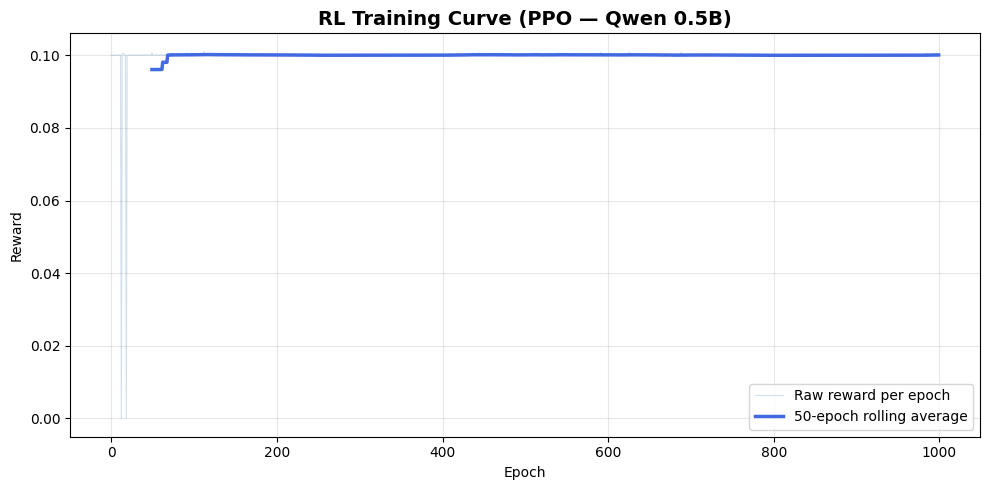

Saved: chart_training_curve.png


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("train_metrics.json") as f:
    metrics = json.load(f)
rewards = metrics["epoch_rewards"]

# 50-epoch rolling average to smooth noise
window = 50
rolling_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rewards, alpha=0.25, color="steelblue", linewidth=0.8, label="Raw reward per epoch")
ax.plot(range(window - 1, len(rewards)), rolling_avg,
        color="royalblue", linewidth=2.5, label=f"{window}-epoch rolling average")
ax.set_title("RL Training Curve (PPO — Qwen 0.5B)", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reward")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart_training_curve.png", dpi=150)
plt.show()
print("Saved: chart_training_curve.png")

## Step 7: Performance Comparison Charts

Two bar charts that tell the full story of our submission:

*Chart 1 — RL vs Baseline:* Compares the average reward of the large 72B generalized model (inference.py) against our tiny 0.5B RL-trained agent. This proves that a smaller model, when trained with Reinforcement Learning via HuggingFace TRL, significantly outperforms a larger model with no task-specific training.

*Chart 2 — Task Score Breakdown:* Shows the final graded score our RL agent achieved on each task difficulty (Easy, Medium, Hard), with the pass threshold marked.

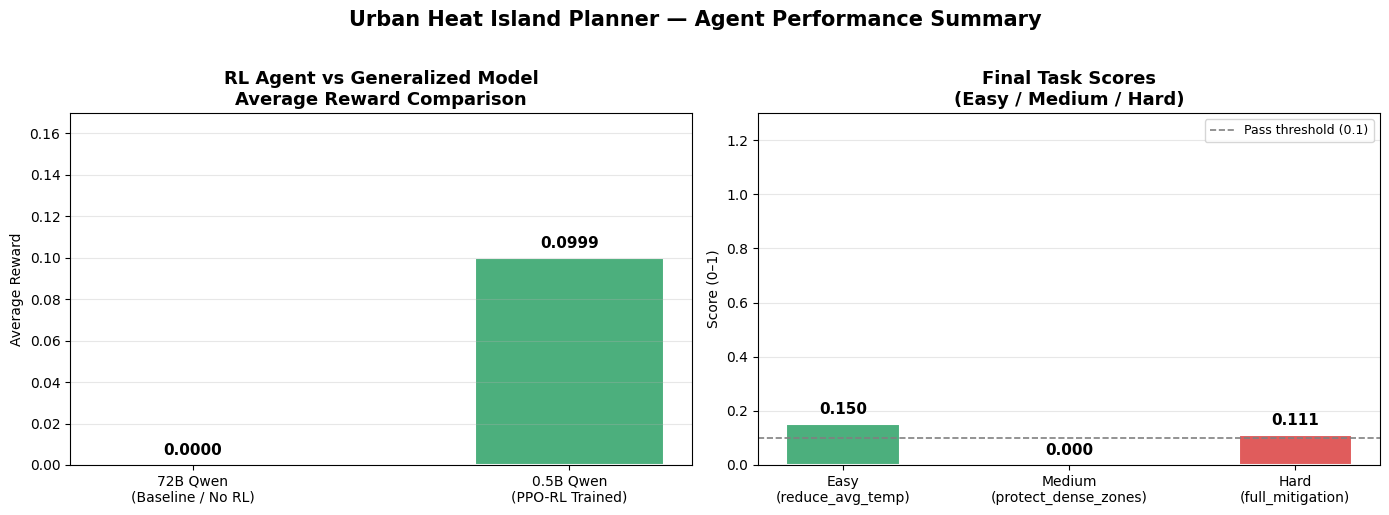

Saved: chart_comparison.png


In [8]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Load training rewards
with open("train_metrics.json") as f:
    metrics = json.load(f)
rewards = metrics["epoch_rewards"]
rl_avg = float(np.mean(rewards))

# Load inference rewards if available, else default to 0.0
inference_avg = 0.0
if os.path.exists("inference_metrics.json"):
    with open("inference_metrics.json") as f:
        inf_metrics = json.load(f)
    all_inf = [r for v in inf_metrics.values() for r in v]
    inference_avg = float(np.mean(all_inf)) if all_inf else 0.0

# Task scores collected in Step 5
task_labels = ["Easy\n(reduce_avg_temp)", "Medium\n(protect_dense_zones)", "Hard\n(full_mitigation)"]
task_ids    = ["reduce_avg_temp", "protect_dense_zones", "full_mitigation"]
task_values = [task_scores.get(tid, 0.0) for tid in task_ids]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart 1: RL vs Baseline
bars1 = ax1.bar(
    ["72B Qwen\n(Baseline / No RL)", "0.5B Qwen\n(PPO-RL Trained)"],
    [inference_avg, rl_avg],
    color=["#e05c5c", "#4caf7d"], width=0.5, edgecolor="white", linewidth=1.5
)
ax1.bar_label(bars1, fmt="%.4f", padding=5, fontsize=11, fontweight="bold")
ax1.set_title("RL Agent vs Generalized Model\nAverage Reward Comparison", fontsize=13, fontweight="bold")
ax1.set_ylabel("Average Reward")
ax1.set_ylim(0, max(rl_avg, inference_avg) * 1.5 + 0.02)
ax1.grid(axis="y", alpha=0.3)

# Bar Chart 2: Task Scores
bars2 = ax2.bar(
    task_labels, task_values,
    color=["#4caf7d", "#f0a500", "#e05c5c"],
    width=0.5, edgecolor="white", linewidth=1.5
)
ax2.bar_label(bars2, fmt="%.3f", padding=5, fontsize=11, fontweight="bold")
ax2.set_title("Final Task Scores\n(Easy / Medium / Hard)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Score (0–1)")
ax2.set_ylim(0, 1.3)
ax2.axhline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Pass threshold (0.1)")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Urban Heat Island Planner — Agent Performance Summary",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_comparison.png")

---
## Step 4: Graceful Shutdown
After training is complete, we terminate the background FastAPI process to free up resources.

In [ ]:
server_process.terminate()
print("Server shut down successfully.")